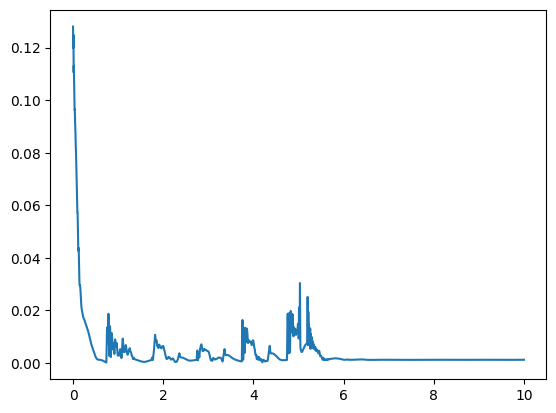

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import sys

folder = '20260426_231208'
#folder = '20260426_185143'

info_w = np.loadtxt(folder + '/dw.csv', delimiter = ',', max_rows = 1)
data_w = np.loadtxt(folder + '/dw.csv', delimiter = ',', skiprows = 1)

t_w = np.linspace(0, info_w[-1], data_w.shape[1])

norm_w = np.zeros((data_w.shape[0]//3, data_w.shape[1]))
for i in range(norm_w.shape[0]):
    norm_w[i][:] = np.linalg.norm(data_w[i*3:i*3 + 3], axis = 0)

plt.plot(t_w, norm_w[1])


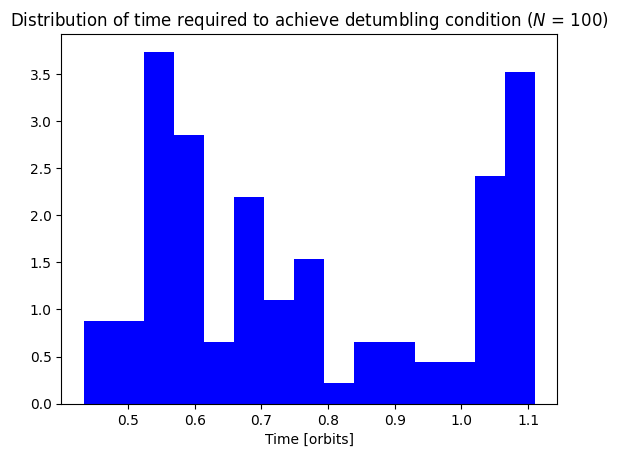

In [92]:
#t_filter = np.array([t[idx[0]] if (idx := np.where(row < 0.0005)[0]).size else np.nan for row in norm])

idx = []
j = 0
for i in range(norm_w.shape[0]): 
    for j in range(np.size(norm_w[i])):
        if norm_w[i][j] < 0.0005:
            idx.append(j)
            break

detumb_times = t_w[idx]

plt.hist(detumb_times, bins = 15, density = True ,color="blue")
plt.xlabel("Time [orbits]")
plt.title("Distribution of time required to achieve detumbling condition ($N$ = 100)")
plt.show()


<>:6: SyntaxWarning: invalid escape sequence '\o'
<>:6: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_10367/468425727.py:6: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\omega$ [rad/s]")


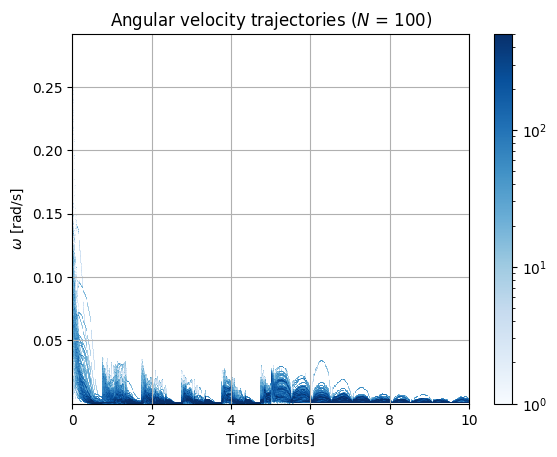

In [87]:
norm_hist = norm_w.reshape(-1)
t_hist = np.tile(t_w, data_w.shape[0]//3)

h = plt.hist2d(t_hist, norm_hist, bins=[500, 500], cmap = 'Blues', norm=LogNorm(vmax=500))
plt.colorbar(h[3])
plt.ylabel("$\omega$ [rad/s]")
plt.xlabel("Time [orbits]")
plt.title("Angular velocity trajectories ($N$ = 100)")
plt.grid()
plt.show()


In [88]:
info_q = np.loadtxt(folder + '/dqs_true.csv', delimiter = ',', max_rows = 1)
data_q = np.loadtxt(folder + '/dqs_true.csv', delimiter = ',', skiprows = 1)

qx = data_q[::3]
qy = data_q[1::3]


Text(0.45, 0.98, 'Partial quaternion trajectories ($N$ = 100)')

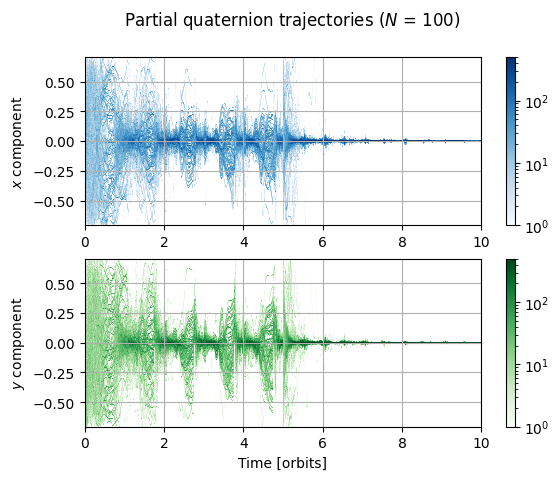

In [89]:
qx_hist = qx.reshape(-1)
qy_hist = qy.reshape(-1)

fig, axs = plt.subplots(2)

h = axs[0].hist2d(t_hist, qx_hist, bins=[500, 500], cmap = 'Blues', norm=LogNorm(vmax=500))
plt.colorbar(h[3])
axs[0].set( ylabel = "$x$ component")
axs[0].grid()

h = axs[1].hist2d(t_hist, qy_hist, bins=[500, 500], cmap = 'Greens', norm=LogNorm(vmax=500))
plt.colorbar(h[3])
axs[1].set( ylabel = "$y$ component", xlabel = "Time [orbits]")
axs[1].grid()

plt.suptitle("Partial quaternion trajectories ($N$ = 100)", x = 0.45)


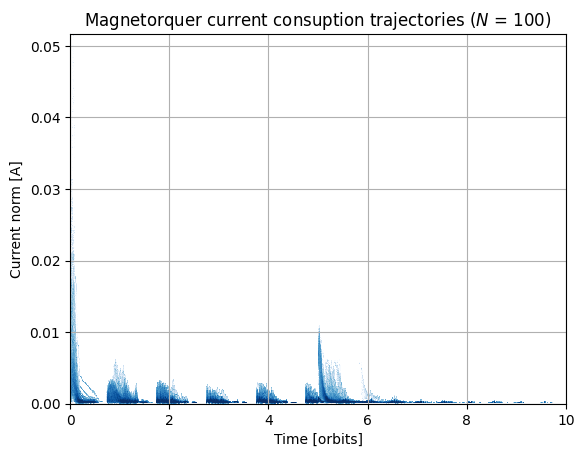

In [90]:
info_I = np.loadtxt(folder + '/current.csv', delimiter = ',', max_rows = 1)
data_I = np.loadtxt(folder + '/current.csv', delimiter = ',', skiprows = 1)

norm_I = np.zeros((data_I.shape[0]//3, data_I.shape[1]))
for i in range(norm_I.shape[0]):
    norm_I[i][:] = np.linalg.norm(data_I[i*3:i*3 + 3], axis = 0)

current_hist = norm_I.reshape(-1)

plt.hist2d(t_hist, current_hist, bins=[500, 500], cmap = 'Blues', norm=LogNorm(vmax=500))
plt.ylabel("Current norm [A]")
plt.xlabel("Time [orbits]")
plt.title("Magnetorquer current consuption trajectories ($N$ = 100)")
plt.grid()
plt.show()



In [91]:
RMS_detumbling = []
RMS_sun_pointing = []
RMS_switch = []
RMS_nadir_pointing = []


orbit_length = int(norm_I.shape[1]/info_I[-1])
switch_index = int(norm_I.shape[1]/2)

for i in range(norm_I.shape[0]):
    detumb_index = idx[i]
    array = norm_I[i][0:detumb_index]
    aux = np.sqrt(np.sum((array)**2)/array.shape[0])
    RMS_detumbling.append(aux)

    array = norm_I[i][detumb_index:switch_index]
    aux = np.sqrt(np.sum((array)**2)/array.shape[0])
    RMS_sun_pointing.append(aux)

    array = norm_I[i][switch_index:(switch_index + orbit_length)]
    aux = np.sqrt(np.sum((array)**2)/array.shape[0])
    RMS_switch.append(aux)

    array = norm_I[i][(switch_index + orbit_length):]
    aux = np.sqrt(np.sum((array)**2)/array.shape[0])
    RMS_nadir_pointing.append(aux)

RMS_detumbling_mean = np.mean(RMS_detumbling)
RMS_sun_pointing_mean = np.mean(RMS_sun_pointing)
RMS_switch_mean = np.mean(RMS_switch)
RMS_nadir_pointing_mean = np.mean(RMS_nadir_pointing)


print(f"RMS medio en detumbling: {RMS_detumbling_mean}")
print(f"RMS medio en sun pointing: {RMS_sun_pointing_mean}")
print(f"RMS medio en el switch: {RMS_switch_mean}")
print(f"RMS medio en el switch: {RMS_nadir_pointing_mean}")


RMS medio en detumbling: 0.0026296426025203133
RMS medio en sun pointing: 0.0005283085411522085
RMS medio en el switch: 0.0013384520495629956
RMS medio en el switch: 0.0002474722401834758
